In [41]:
# Magnetic Daily Variation Analysis, based on hourly mean values, Lecture 2, Inverse Problems MSc
# Chris Finlay, Mikkel Otzen and Nils Olsen

In [42]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import scipy.io as spio

In [43]:
data = spio.loadmat("B_X_2008.mat")

In [44]:
data

{'__header__': b'MATLAB 5.0 MAT-file, Platform: PCWIN64, Created on: Mon Feb 02 13:23:05 2015',
 '__version__': '1.0',
 '__globals__': [],
 't': array([[2922.02083333],
        [2922.0625    ],
        [2922.10416667],
        ...,
        [3287.89583333],
        [3287.9375    ],
        [3287.97916667]]),
 'Kp': array([[17],
        [17],
        [17],
        ...,
        [23],
        [23],
        [23]], dtype=uint8),
 'X_CMO': array([[11604.2],
        [11608.2],
        [11609.2],
        ...,
        [11618.3],
        [11627.2],
        [11627.2]]),
 'X_BOU': array([[20460.2],
        [20459.2],
        [20459.2],
        ...,
        [20447.6],
        [20455.6],
        [20458.6]])}

In [45]:
t = data["t"]
ts = t*(24*60*60) # from days to seconds
Kp = data["Kp"]
X_CMO = data["X_CMO"] - np.nanmean(data["X_CMO"])
X_BOU = data["X_BOU"] - np.nanmean(data["X_BOU"])

In [46]:
epoch = np.array('2000-01-01', dtype="datetime64[s]") # Define starting epoch
tseries = epoch + ts.astype(int) # Generate time-series for plotting

In [47]:
tseries

array([['2008-01-01T00:30:00'],
       ['2008-01-01T01:30:00'],
       ['2008-01-01T02:30:00'],
       ...,
       ['2008-12-31T21:30:00'],
       ['2008-12-31T22:30:00'],
       ['2008-12-31T23:30:00']], dtype='datetime64[s]')

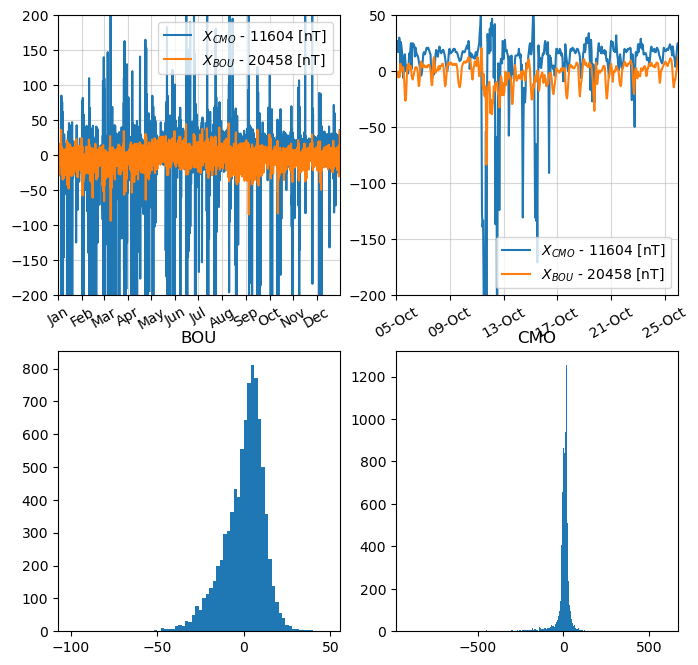

In [48]:
# Limits and formatting for iterating over subplots
formats = [mdates.DateFormatter("%b"), mdates.DateFormatter("%d-%b")] # https://docs.python.org/3/library/datetime.html#strftime-strptime-behavior

xlims = [(np.datetime64('2008-01-01'), np.datetime64('2008-12-31')),
        (np.datetime64('2008-10-05'), np.datetime64('2008-10-26'))]

ylims = [(-200,200), (-200,50)]


fig = plt.figure(figsize=(8,8))
gs = fig.add_gridspec(2, 2)

for i in np.arange(2):
    ax = fig.add_subplot(gs[i]) 
    ax.plot(tseries, X_CMO, label="$X_{{CMO}}$ - {:.0f} [nT]".format(np.nanmean(data["X_CMO"])))
    ax.plot(tseries, X_BOU, label="$X_{{BOU}}$ - {:.0f} [nT]".format(np.nanmean(data["X_BOU"])))
    ax.set_xlim(xlims[i])
    ax.set_ylim(ylims[i])
    ax.xaxis.set_major_formatter(formats[i])
    ax.legend()
    ax.grid(alpha=0.5)
    for label in ax.get_xticklabels():
        label.set_rotation(30)


XS = [(X_BOU,"BOU",np.arange(-100,50,2)), (X_CMO,"CMO",np.arange(-900,600,5))]
for i in np.arange(2,4):
    ax = fig.add_subplot(gs[i])
    ax.hist(XS[i-2][0], bins = XS[i-2][2])
    ax.set_title(XS[i-2][1])
plt.show()

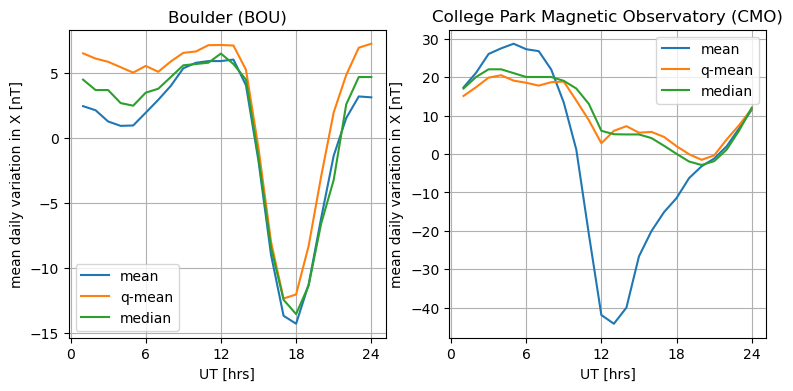

In [49]:
# A quick exploratory look at the mean, quiet time mean, and Median of values for each hour of the day

Kp_max = 20  # Threshold for quiet times

# BOU
X_BOU_sub = X_BOU.copy()
X_BOU_sub[Kp>=Kp_max] = np.nan # Remove high kp

X_BOU_24 = X_BOU.reshape(-1,24) # Reshape into hours
X_BOU_24_sub = X_BOU_sub.reshape(-1,24)

# CMO
X_CMO_sub = X_CMO.copy()
X_CMO_sub[Kp>=Kp_max] = np.nan # Remove high kp

X_CMO_24 = X_CMO.reshape(-1,24) # Reshape into hours
X_CMO_24_sub = X_CMO_sub.reshape(-1,24)

# Figure
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(9,4))
hours = np.arange(1,24+1,1)
xticks = np.arange(0,24+6,6)
# BOU
ax1.plot(hours,np.nanmean(X_BOU_24,axis=0), label="mean")
ax1.plot(hours,np.nanmean(X_BOU_24_sub,axis=0), label="q-mean")
ax1.plot(hours,np.nanmedian(X_BOU_24,axis=0), label="median")
ax1.legend()
ax1.set_xlabel('UT [hrs]')
ax1.set_ylabel('mean daily variation in X [nT]')
ax1.set_title("Boulder (BOU)")
ax1.set_xticks(xticks)
ax1.grid()
# CMO
ax2.plot(hours,np.nanmean(X_CMO_24,axis=0), label="mean")
ax2.plot(hours,np.nanmean(X_CMO_24_sub,axis=0), label="q-mean")
ax2.plot(hours,np.nanmedian(X_CMO_24,axis=0), label="median")
ax2.legend()
ax2.set_xlabel('UT [hrs]')
ax2.set_ylabel('mean daily variation in X [nT]')
ax2.set_title('College Park Magnetic Observatory (CMO)')
ax2.set_xticks(xticks)
ax2.grid()

plt.show()

In [50]:
## Set up functions to determine expected daily variation (edv) via Fourier method

# Setup of G matrix and doing solve, all data and quiet time data
# Does simple least squares and Robust Estimates (Huber and Tukey) with 10 iterations

def edv_Fourier(X, X_sub, t, tag = None):
    print("__", tag, "__")
    
    index = np.invert(np.isnan(X))

    G = np.ones(len(X[index]))

    for n in np.arange(1,6+1):
        G = np.vstack((G, np.cos(n*2*np.pi*t[index]), np.sin(n*2*np.pi*t[index])))

    G = G.T
    d = X[index]
    
    print("G.shape: ", G.shape)
    print("d.shape: ", d.shape)
    print("m.shapes: ({},)".format(G.shape[1]))
    
    # Parameters in robust distributions
    c=1.5  # Huber
    c2=4.685 # Tukey

    W = np.diag(np.ones(len(d)))
    m_LS = np.linalg.solve((G.T@G), (G.T@d))
    d_model = G@m_LS
    res=d-d_model  # Dimensional residual 
    sigma_est=np.sqrt(np.sum(res**2)/len(res))  # 1st estimate of dispersion sigma

    N_iter = 10 # In this simple example have fixed max number of iterations
    m_H, w_H = IRLS_w(N_iter, G, d, sigma_est, c, W_type = "huber")
    m_T, w_T = IRLS_w(N_iter, G, d, sigma_est, c2, W_type = "tukey")

    # quiet data inversion 
    indexq = np.invert(np.isnan(X_sub))
    G_sub = np.ones(len(X_sub[indexq]))

    for n in np.arange(1,6+1):
        G_sub = np.vstack((G_sub, np.cos(n*2*np.pi*t[indexq]), np.sin(n*2*np.pi*t[indexq])))

    G_sub = G_sub.T
    dq = X[indexq]

    m_LS_q = np.linalg.solve((G_sub.T@G_sub), (G_sub.T@dq))
    dq_model = G_sub@m_LS_q
    
    print("m_LS: ", m_LS, end="\n")
    print("m_H: ", m_H, end="\n")
    print("m_T: ", m_T, end="\n")
    print("m_LS: ", m_LS_q, end="\n")
    print("\n")
    return m_LS, (m_H, w_H), (m_T, w_T), m_LS_q

# Iterative solver with options for Huber and Tukey weights
def IRLS_w(N_iter, G, d, sigma, c, W_type = "huber"):
    w = np.ones(len(d))
    ones_min = np.ones(len(d))
    for i in np.arange(1,N_iter+1):
        W = np.diag(w)
        m_IRLS = np.linalg.solve((G.T@W@G), ((G.T@W@d)))
        d_model_IRLS = G@m_IRLS
        epsilon = (d - d_model_IRLS)/sigma
        if W_type == "huber":
            w = np.min([c/abs(epsilon),ones_min],axis=0) # Huber
        elif W_type == "tukey":
            w = (1-(epsilon/c)**2)**2; #Tukey
            w[abs(epsilon) >= c] = 0.0

    return m_IRLS, w

In [51]:
# Solve Inverse problem to find Fourier Coefficients

# model of mean plus daily variation, Boulder
m_LS_B, H_B, T_B, m_LS_q_B = edv_Fourier(X_BOU, X_BOU_sub, t, tag = "BOU")

# model of mean plus daily variation, College Station
m_LS_C, H_C, T_C, m_LS_q_C = edv_Fourier(X_CMO, X_CMO_sub, t, tag = "CMO")

# For plotting model results for daily variation
t_daily=np.arange(0,1+1/48,1/48) # one day
G_daily = np.ones(len(t_daily))

# Associated design matrix
for n in np.arange(1,6+1):
    G_daily = np.vstack((G_daily, np.cos(n*2*np.pi*t_daily), np.sin(n*2*np.pi*t_daily)))
G_daily = G_daily.T    
    
t_comp=np.arange(1,24+1)
t_comp=t_comp-0.5

__ BOU __
G.shape:  (8731, 13)
d.shape:  (8731,)
m.shapes: (13,)
m_LS:  [-0.01980297 -0.63606423  5.90036533  5.07728117 -2.48748329 -1.25193094
 -2.00236215 -0.42620421  0.95435412  0.23809866 -0.21189113 -0.16644845
  0.10734843]
m_H:  [ 0.27154161 -0.41127547  6.04402207  5.06805605 -2.26512512 -1.17435389
 -2.03661142 -0.40946473  0.79521064  0.16807438 -0.24991699 -0.19224177
  0.0897885 ]
m_T:  [ 0.40192607 -0.31453716  6.08649164  5.0617354  -2.19754628 -1.12930281
 -2.02861005 -0.36554694  0.73993595  0.15507724 -0.27674305 -0.20021153
  0.08881219]
m_LS:  [ 2.5534869   1.09437472  6.20922408  5.01547416 -2.25560863 -1.64168485
 -1.93100725 -0.30502462  0.92213421  0.31802153 -0.32404728 -0.15809273
  0.02747031]


__ CMO __
G.shape:  (8728, 13)
d.shape:  (8728,)
m.shapes: (13,)
m_LS:  [  0.03115226  22.18553819  19.13616841 -11.74490471  -1.29651448
   5.81290976   1.08368081  -3.1116704    0.42693556   1.71844016
  -0.15731927  -0.65385238  -0.15317967]
m_H:  [ 5.55101202 12.

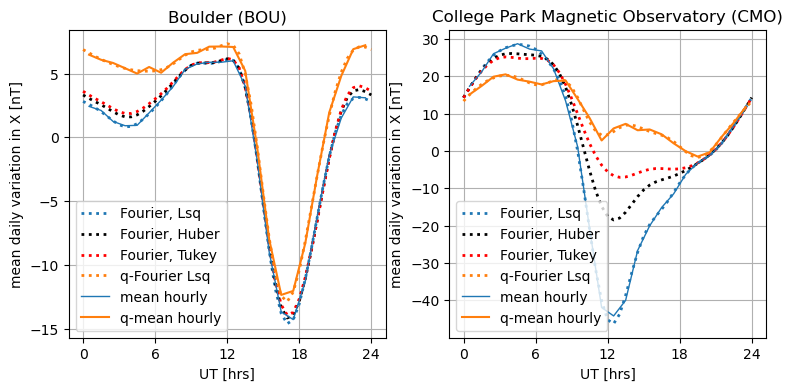

In [52]:
# Plot results of Fourier Analysis models
fig, (ax1,ax2) = plt.subplots(1,2,figsize=(9,4))
hours = np.arange(1,24+1,1)
xticks = np.arange(0,24+6,6)

# Model result plots for BOU
x_daily_LS=G_daily@m_LS_B  #Predictions
x_daily_H=G_daily@H_B[0]
x_daily_T=G_daily@T_B[0]
x_daily_LS_q=G_daily@m_LS_q_B

ax1.plot(t_daily*24,x_daily_LS, ':C0', linewidth = 2, label = "Fourier, Lsq")
ax1.plot(t_daily*24,x_daily_H, ':k', linewidth = 2, label = "Fourier, Huber")
ax1.plot(t_daily*24,x_daily_T, ':r', linewidth = 2, label = "Fourier, Tukey")
ax1.plot(t_daily*24,x_daily_LS_q, ':C1', linewidth = 2, label = "q-Fourier Lsq")
ax1.plot(t_comp,np.nanmean(X_BOU_24,axis=0), '-C0', linewidth = 1, label = "mean hourly")
ax1.plot(t_comp,np.nanmean(X_BOU_24_sub,axis=0), '-C1', linewidth = 1.5, label = "q-mean hourly")

ax1.legend()
ax1.set_xlabel('UT [hrs]')
ax1.set_ylabel('mean daily variation in X [nT]')
ax1.set_title("Boulder (BOU)")
ax1.set_xticks(xticks)
ax1.grid()

# Model result plots for CMO
x_daily_LS=G_daily@m_LS_C  #Predictions
x_daily_H=G_daily@H_C[0]
x_daily_T=G_daily@T_C[0]
x_daily_LS_q=G_daily@m_LS_q_C

ax2.plot(t_daily*24,x_daily_LS, ':C0', linewidth = 2, label = "Fourier, Lsq")
ax2.plot(t_daily*24,x_daily_H, ':k', linewidth = 2, label = "Fourier, Huber")
ax2.plot(t_daily*24,x_daily_T, ':r', linewidth = 2, label = "Fourier, Tukey")
ax2.plot(t_daily*24,x_daily_LS_q, ':C1', linewidth = 2, label = "q-Fourier Lsq")
ax2.plot(t_comp,np.nanmean(X_CMO_24,axis=0), '-C0', linewidth = 1, label = "mean hourly")
ax2.plot(t_comp,np.nanmean(X_CMO_24_sub,axis=0), '-C1', linewidth = 1.5, label = "q-mean hourly")
ax2.legend()
ax2.set_xlabel('UT [hrs]')
ax2.set_ylabel('mean daily variation in X [nT]')
ax2.set_title('College Park Magnetic Observatory (CMO)')
ax2.set_xticks(xticks)
ax2.grid()

plt.show()

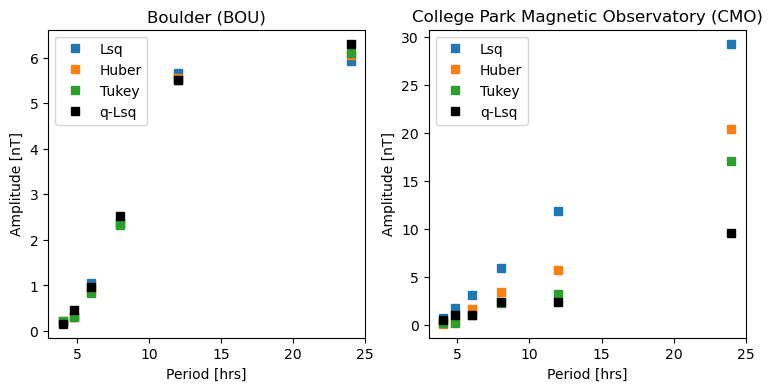

In [53]:
# Plot results for model coefficients

i = np.arange(1,6+1)

i2 = 2*(i-1)+1
i3 = 2*(i-1)+2

a_LS_B = np.sqrt(m_LS_B[i2]**2 + m_LS_B[i3]**2)
a_H_B = np.sqrt(H_B[0][i2]**2 + H_B[0][i3]**2)
a_T_B = np.sqrt(T_B[0][i2]**2 + T_B[0][i3]**2)
a_LS_q_B = np.sqrt(m_LS_q_B[i2]**2 + m_LS_q_B[i3]**2)

a_LS_C = np.sqrt(m_LS_C[i2]**2 + m_LS_C[i3]**2)
a_H_C = np.sqrt(H_C[0][i2]**2 + H_C[0][i3]**2)
a_T_C = np.sqrt(T_C[0][i2]**2 + T_C[0][i3]**2)
a_LS_q_C = np.sqrt(m_LS_q_C[i2]**2 + m_LS_q_C[i3]**2)

t_a = [24, 12, 8, 6, 4.8, 4]

fig, (ax1,ax2) = plt.subplots(1,2,figsize=(9,4))
ax1.plot(t_a, a_LS_B, "s", label = "Lsq")
ax1.plot(t_a, a_H_B, "s", label = "Huber")
ax1.plot(t_a, a_T_B, "s", label = "Tukey")
ax1.plot(t_a, a_LS_q_B, "sk", label = "q-Lsq")
ax1.set_xlabel('Period [hrs]')
ax1.set_ylabel('Amplitude [nT]')
ax1.set_title('Boulder (BOU)')
ax1.legend()

ax2.plot(t_a, a_LS_C, "s", label = "Lsq")
ax2.plot(t_a, a_H_C, "s", label = "Huber")
ax2.plot(t_a, a_T_C, "s", label = "Tukey")
ax2.plot(t_a, a_LS_q_C, "sk", label = "q-Lsq")
ax2.set_xlabel('Period [hrs]')
ax2.set_ylabel('Amplitude [nT]')
ax2.set_title('College Park Magnetic Observatory (CMO)')
ax2.legend()
plt.show()

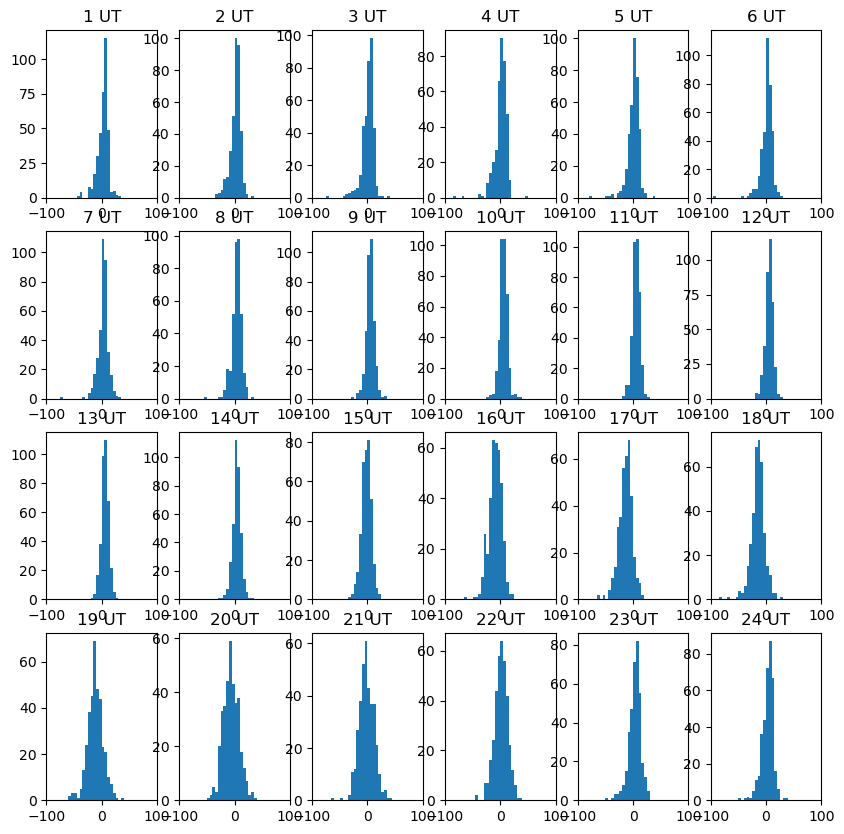

In [54]:
## Explanation: Constable (1988), N. Olsen PhD thesis
## Not i.i.d across hours
## Probability distributions are skewed, and not stationary
## Show histograms for hours

# BOU histograms
bins = np.arange(-100,50+5,5)
fig = plt.figure(figsize=(10,10))
gs = fig.add_gridspec(4, 6)
for j in np.arange(0,24):
    ax = fig.add_subplot(gs[j]) 
    ax.hist(X_BOU_24[:,j], bins = bins)
    ax.set_title("{} UT".format(j+1))
    ax.set_xlim(-100,100)
plt.show()

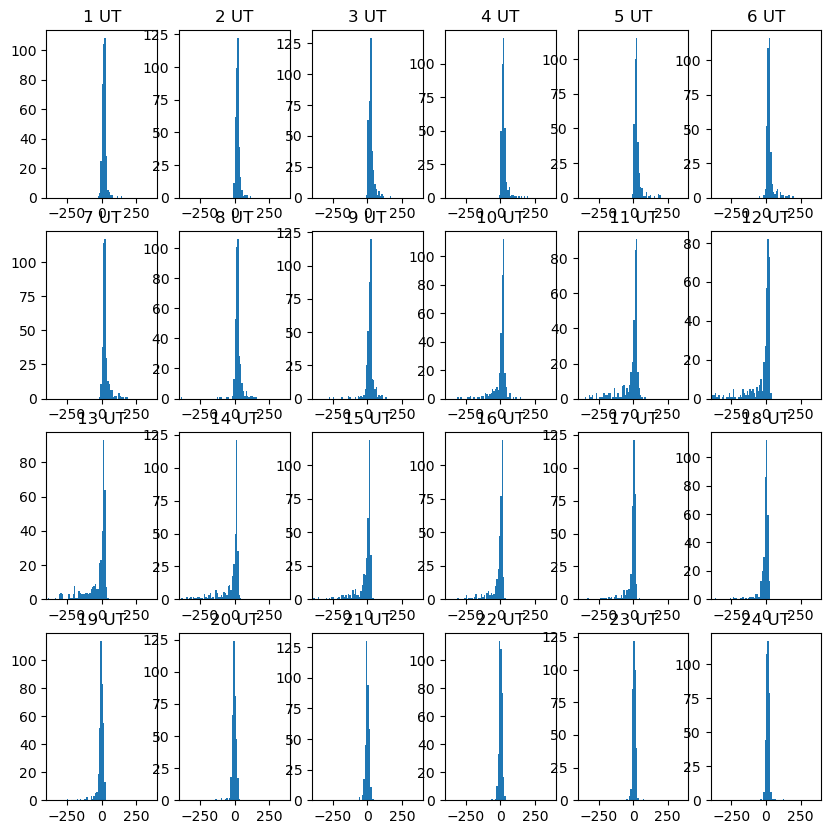

In [55]:
#CMO histograms
bins = np.arange(-600,200+5,10)
fig = plt.figure(figsize=(10,10))
gs = fig.add_gridspec(4, 6)
for j in np.arange(0,24):
    ax = fig.add_subplot(gs[j]) 
    ax.hist(X_CMO_24[:,j], bins = bins)
    ax.set_title("{} UT".format(j+1))
    ax.set_xlim(-400,400)
plt.show()

In [56]:
# Conclusion: Understand physics of signals understudy
# Make appropriate data selection for topic under study
# If in doubt choose robust methods (IRLS)